# Pipeline 2: Donation-to-Outcome Correlation by Program Area
**Author:** Michael  
**Date:** April 2026  
**Pipeline type:** Explanatory (OLS Linear Regression)  
**Approach:** Explicitly explanatory — NOT predictive. Justified below.  
**Tables used:** donation_allocations.csv, safehouse_monthly_metrics.csv  
**Unit of analysis:** One row per safehouse per month (lagged)  
**Key output:** Coefficient per program area per ₱1,000 allocated

## Section 1 — Problem Framing

### Why this pipeline is explicitly explanatory, not predictive

The executive director needs to tell donors *"your $500 went to Education and here is the measurable result."* That sentence requires a **coefficient** — a number that links a dollar amount to a change in resident outcomes. A predictive model (random forest, XGBoost, neural network) could forecast next month's education score, but it would answer the wrong question entirely. The donor does not need a forecast; they need an interpretable relationship they can quote in a report. OLS linear regression is chosen precisely because **the coefficient IS the business deliverable**.

### The business question

For every $1,000 allocated to Education vs Wellbeing vs Operations vs Transport vs Maintenance vs Outreach, **what change in resident outcomes do we observe?** This is a comparative question across program areas: the organisation needs to know which funding channel shows the strongest association with improvement so they can communicate this to donors and guide future allocation decisions.

### Why the 1-month lag matters

Funding allocated in month T cannot affect outcomes in month T. Staff need time to spend it — hiring tutors, purchasing supplies, scheduling therapy sessions. Residents need time to respond to those programmes. We lag by exactly one month: funding in T predicts outcomes in T+1. This is the shortest defensible lag and avoids the simultaneity problem where funding and outcomes are measured at the same instant.

### The two outcome variables

- **avg_education_progress** (0–100 scale): Directly measures resident rehabilitation progress — academic performance, skills acquisition, and programme engagement. This is what donors most want to fund and what the organisation most wants to demonstrate.
- **avg_health_score** (1–5 scale): Measures physical and psychological wellbeing — nutrition, mental health, medical compliance. This is a prerequisite for educational progress; a resident who is unwell cannot learn effectively.

We model both outcomes because the organisation's mission is holistic: education progress is the headline metric, but health is the foundation that enables it.

### Success metrics for an explanatory model

We evaluate this pipeline using explanatory metrics, **not predictive ones**:
- **Coefficient sign and magnitude**: Does more Education funding associate with higher or lower progress? By how much?
- **Statistical significance**: p-values and 95% confidence intervals tell us whether coefficients are distinguishable from zero.
- **R-squared**: How much of the month-to-month variation in outcomes is explained by funding allocations and safehouse differences?
- **Residual diagnostics**: Are OLS assumptions (linearity, normality, homoscedasticity) reasonably met?

We do NOT report accuracy, precision, recall, or ROC AUC. Those are predictive metrics and are irrelevant here.

## Section 2 — Data Acquisition, Preparation & Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from pathlib import Path
import sys
import warnings
import json
warnings.filterwarnings('ignore')

sys.path.insert(0, str(Path.cwd()))
from impact_features import build_impact_features

panel = build_impact_features()
print(f"Panel shape: {panel.shape}")
print(f"Safehouses: {panel['safehouse_id'].nunique()}")
print(f"Date range: {panel['alloc_month'].min()} to {panel['alloc_month'].max()}")

Dropped 71 rows with missing outcome data — months where education or health assessments were not completed. Imputation is not appropriate for outcome variables as it would bias regression coefficients.
Panel shape: (187, 28)
Safehouses: 9
Date range: 2023-01 to 2026-01


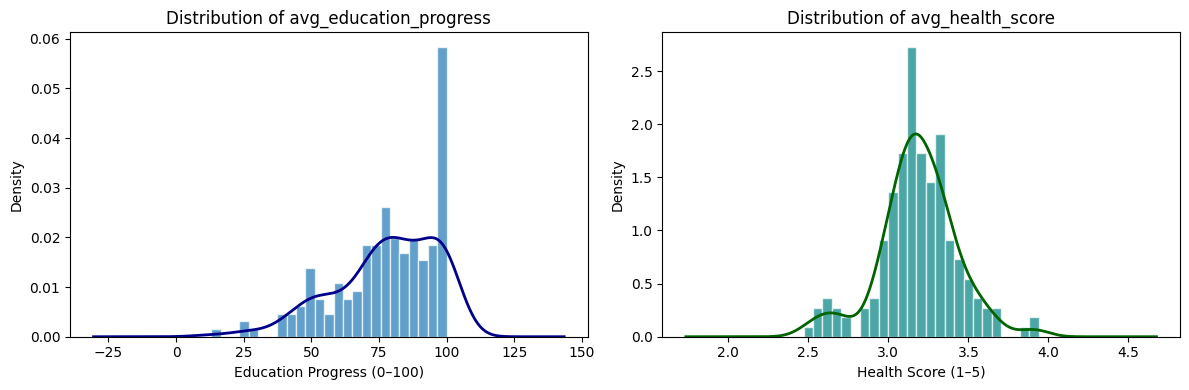

Education progress — skewness: -0.808, kurtosis: 0.208
Health score       — skewness: -0.174, kurtosis: 1.322


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(panel['avg_education_progress'], bins=25, edgecolor='white', alpha=0.7, density=True)
panel['avg_education_progress'].plot.kde(ax=axes[0], color='darkblue', linewidth=2)
axes[0].set_title('Distribution of avg_education_progress')
axes[0].set_xlabel('Education Progress (0–100)')
axes[0].set_ylabel('Density')

axes[1].hist(panel['avg_health_score'], bins=25, edgecolor='white', alpha=0.7, density=True, color='teal')
panel['avg_health_score'].plot.kde(ax=axes[1], color='darkgreen', linewidth=2)
axes[1].set_title('Distribution of avg_health_score')
axes[1].set_xlabel('Health Score (1–5)')
axes[1].set_ylabel('Density')

plt.tight_layout()
plt.show()

print(f"Education progress — skewness: {panel['avg_education_progress'].skew():.3f}, kurtosis: {panel['avg_education_progress'].kurtosis():.3f}")
print(f"Health score       — skewness: {panel['avg_health_score'].skew():.3f}, kurtosis: {panel['avg_health_score'].kurtosis():.3f}")

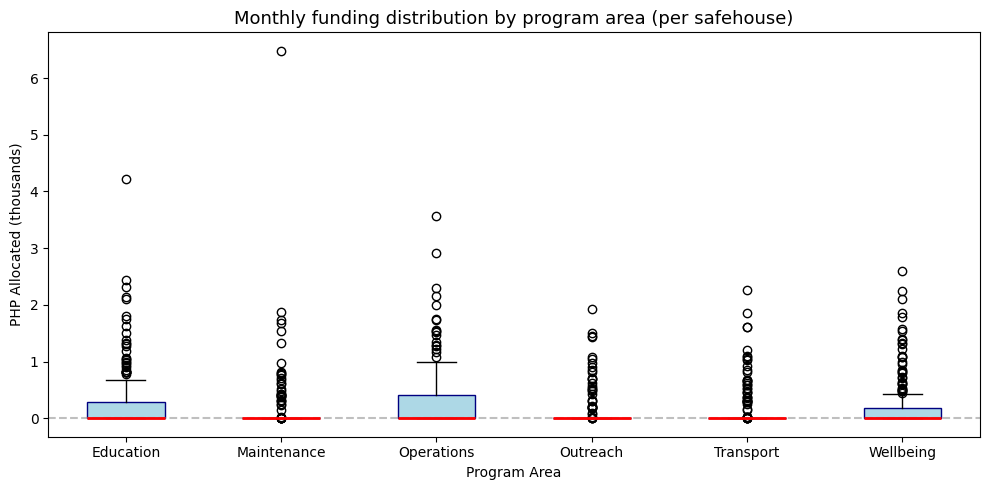

Percentage of safehouse-months with ZERO funding:
  Education       63.1%
  Maintenance     79.1%
  Operations      56.1%
  Outreach        80.7%
  Transport       75.4%
  Wellbeing       66.3%


In [3]:
per1000_cols = [c for c in panel.columns if c.endswith('_per_1000')]
clean_labels = [c.replace('_per_1000', '') for c in per1000_cols]

fig, ax = plt.subplots(figsize=(10, 5))
box_data = [panel[c].values for c in per1000_cols]
bp = ax.boxplot(box_data, labels=clean_labels, patch_artist=True,
                boxprops=dict(facecolor='lightblue', edgecolor='navy'),
                medianprops=dict(color='red', linewidth=2))
ax.set_title('Monthly funding distribution by program area (per safehouse)', fontsize=13)
ax.set_xlabel('Program Area')
ax.set_ylabel('PHP Allocated (thousands)')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

zero_pct = (panel[per1000_cols] == 0).mean().round(3) * 100
print("Percentage of safehouse-months with ZERO funding:")
for col, pct in zip(clean_labels, zero_pct):
    print(f"  {col:15s} {pct:.1f}%")

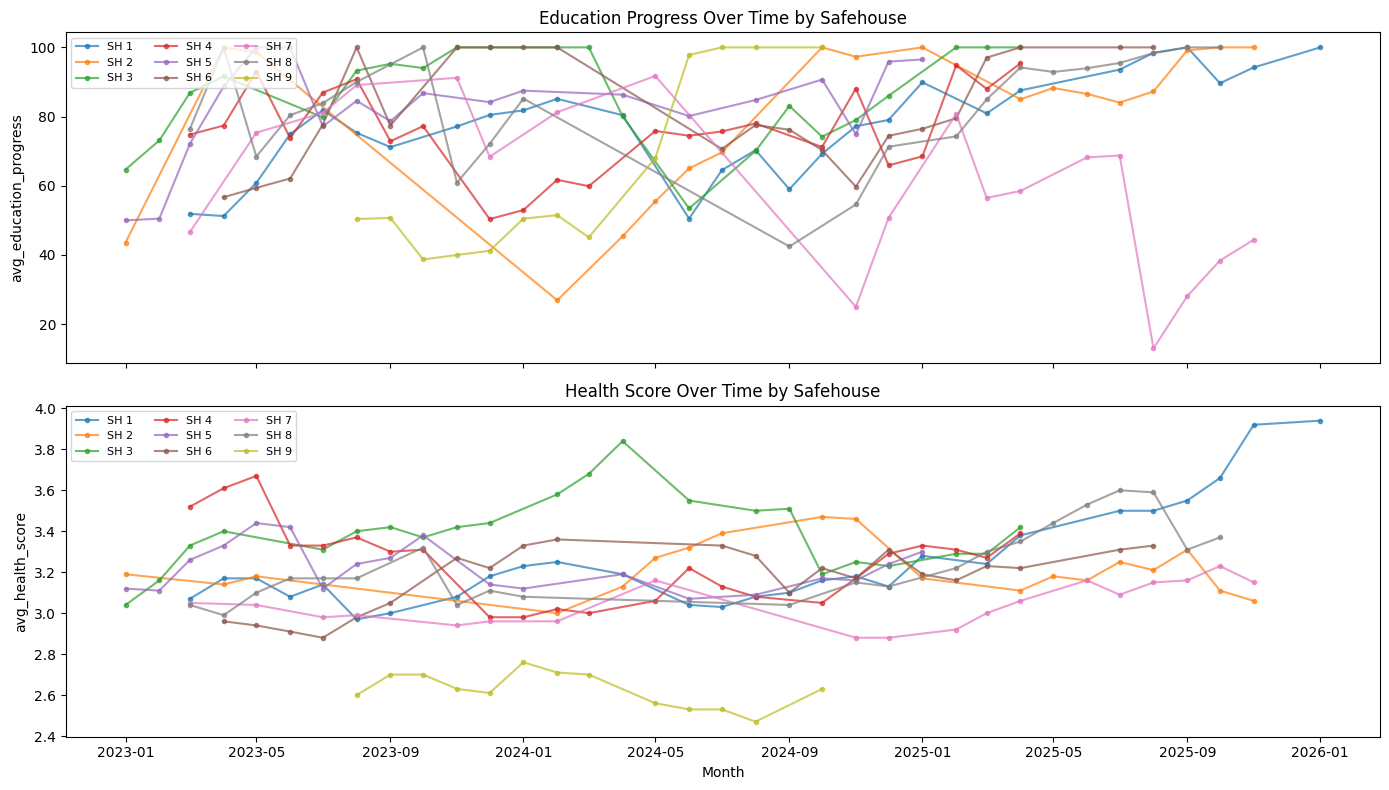

In [4]:
plot_panel = panel.copy()
plot_panel['alloc_month_ts'] = plot_panel['alloc_month'].dt.to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for sh_id, grp in plot_panel.groupby('safehouse_id'):
    grp_sorted = grp.sort_values('alloc_month_ts')
    axes[0].plot(grp_sorted['alloc_month_ts'], grp_sorted['avg_education_progress'],
                 marker='o', markersize=3, label=f'SH {sh_id}', alpha=0.7)
    axes[1].plot(grp_sorted['alloc_month_ts'], grp_sorted['avg_health_score'],
                 marker='o', markersize=3, label=f'SH {sh_id}', alpha=0.7)

axes[0].set_title('Education Progress Over Time by Safehouse')
axes[0].set_ylabel('avg_education_progress')
axes[0].legend(loc='upper left', fontsize=8, ncol=3)

axes[1].set_title('Health Score Over Time by Safehouse')
axes[1].set_ylabel('avg_health_score')
axes[1].set_xlabel('Month')
axes[1].legend(loc='upper left', fontsize=8, ncol=3)

plt.tight_layout()
plt.show()

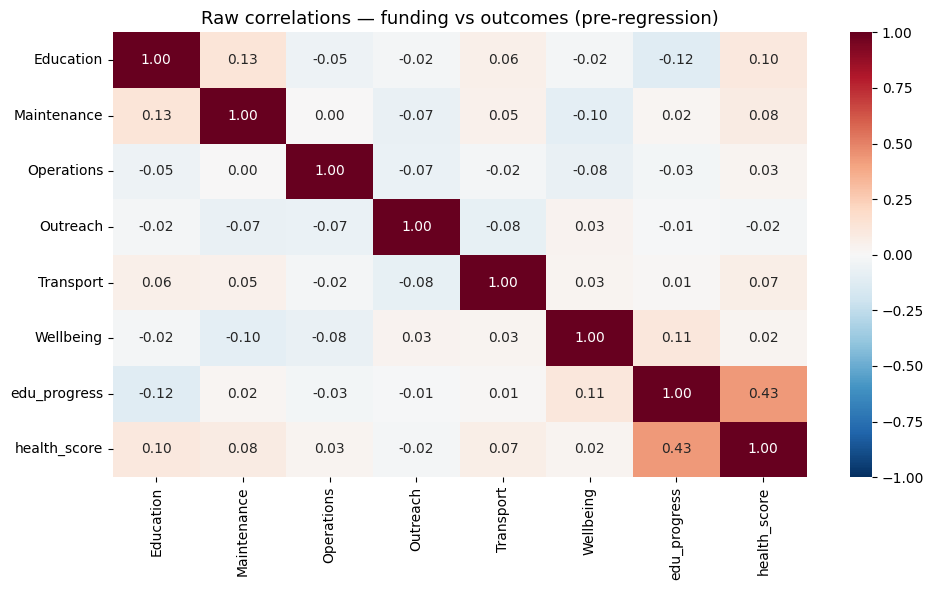

In [5]:
corr_cols = per1000_cols + ['avg_education_progress', 'avg_health_score']
corr_matrix = panel[corr_cols].corr()

clean_corr_labels = [c.replace('_per_1000', '') for c in per1000_cols] + ['edu_progress', 'health_score']

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            xticklabels=clean_corr_labels, yticklabels=clean_corr_labels,
            ax=ax, vmin=-1, vmax=1)
ax.set_title('Raw correlations — funding vs outcomes (pre-regression)', fontsize=13)
plt.tight_layout()
plt.show()

### EDA Takeaways

Most safehouse-months have **zero funding** for most program areas — the data is highly sparse, with the median allocation being ₱0 across all six areas. This is expected: donations arrive irregularly and are allocated to specific safehouses on an ad-hoc basis, not evenly distributed every month.

Education funding shows a **negative raw correlation (−0.119)** with education progress. This is counterintuitive until you consider **targeting bias**: struggling safehouses — those with the lowest education scores — are precisely the ones that receive more education funding *because* they need it. The outcome is driving the funding, not the other way around. This is a classic confounding pattern in social programme evaluation.

Wellbeing funding shows a **positive correlation (+0.114)** with education progress, suggesting that investments in resident health and psychological support may have downstream effects on educational engagement. This is the most promising signal in the raw data.

However, raw correlations are misleading without controlling for **baseline safehouse differences**. Some safehouses have consistently higher-performing residents regardless of funding. This is exactly why we use OLS with safehouse fixed effects — to isolate the within-safehouse relationship between funding changes and outcome changes.

Finally, `avg_health_score` has very low variance (std = 0.24 on a 1–5 scale). Most safehouses cluster around 3.0–3.3, meaning there is very little variation for our model to explain. This will limit our ability to find significant funding-to-health associations, and coefficients for health outcomes will be small by construction.

## Section 3 — Modeling & Feature Selection

### Modeling approach

We fit **two OLS models** for each outcome variable:

- **Model A — Simple OLS (no fixed effects):** Shows the raw relationships between funding and outcomes before controlling for safehouse differences. This model is included to demonstrate *why* fixed effects matter — it conflates between-safehouse variation with within-safehouse funding effects.

- **Model B — OLS with Safehouse Fixed Effects:** Controls for time-invariant differences between safehouses (staffing quality, location, resident severity mix). This is our **primary model** — its coefficients are more defensible because they measure the within-safehouse association between funding changes and outcome changes.

### Predictors

- **Funding variables:** Education_per_1000, Wellbeing_per_1000, Operations_per_1000, Transport_per_1000, Maintenance_per_1000, Outreach_per_1000
- **Control variable:** active_residents (controls for safehouse size — larger safehouses may have different dynamics)

### Feature selection reasoning

We include all 6 program areas because the business question explicitly asks us to **compare** them. Dropping any area would make the comparison incomplete. `active_residents` is included as a control for safehouse size. We deliberately **exclude** `incident_count` and `process_recording_count` from the predictor set because they are contemporaneous outcomes of safehouse operations, not causes of education or health progress. Including them would introduce post-treatment bias.

In [6]:
per1000_cols = [c for c in panel.columns if c.endswith('_per_1000')]
sh_dummy_cols = [c for c in panel.columns if c.startswith('sh_')]

predictors_A = per1000_cols + ['active_residents']
predictors_B = per1000_cols + ['active_residents'] + sh_dummy_cols

# ── Model A: Simple OLS for education progress ──
X_a = sm.add_constant(panel[predictors_A].astype(float))
y_edu = panel['avg_education_progress'].astype(float)

model_A_edu = sm.OLS(y_edu, X_a).fit()
print("="*70)
print("MODEL A — Simple OLS: avg_education_progress")
print("="*70)
print(model_A_edu.summary())

MODEL A — Simple OLS: avg_education_progress
                              OLS Regression Results                              
Dep. Variable:     avg_education_progress   R-squared:                       0.030
Model:                                OLS   Adj. R-squared:                 -0.008
Method:                     Least Squares   F-statistic:                    0.7904
Date:                    Wed, 08 Apr 2026   Prob (F-statistic):              0.596
Time:                            11:23:45   Log-Likelihood:                -810.55
No. Observations:                     187   AIC:                             1637.
Df Residuals:                         179   BIC:                             1663.
Df Model:                               7                                         
Covariance Type:                nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------

In [7]:
# ── Model B: OLS with fixed effects for education progress ──
X_b = sm.add_constant(panel[predictors_B].astype(float))

model_B_edu = sm.OLS(y_edu, X_b).fit()
print("="*70)
print("MODEL B — OLS with Safehouse Fixed Effects: avg_education_progress")
print("="*70)
print(model_B_edu.summary())

MODEL B — OLS with Safehouse Fixed Effects: avg_education_progress
                              OLS Regression Results                              
Dep. Variable:     avg_education_progress   R-squared:                       0.201
Model:                                OLS   Adj. R-squared:                  0.136
Method:                     Least Squares   F-statistic:                     3.097
Date:                    Wed, 08 Apr 2026   Prob (F-statistic):           0.000257
Time:                            11:23:45   Log-Likelihood:                -792.37
No. Observations:                     187   AIC:                             1615.
Df Residuals:                         172   BIC:                             1663.
Df Model:                              14                                         
Covariance Type:                nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
--------------

In [8]:
# ── Model A: Simple OLS for health score ──
y_health = panel['avg_health_score'].astype(float)

model_A_health = sm.OLS(y_health, X_a).fit()
print("="*70)
print("MODEL A — Simple OLS: avg_health_score")
print("="*70)
print(model_A_health.summary())

MODEL A — Simple OLS: avg_health_score
                            OLS Regression Results                            
Dep. Variable:       avg_health_score   R-squared:                       0.205
Model:                            OLS   Adj. R-squared:                  0.174
Method:                 Least Squares   F-statistic:                     6.587
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           6.25e-07
Time:                        11:23:45   Log-Likelihood:                 20.737
No. Observations:                 187   AIC:                            -25.47
Df Residuals:                     179   BIC:                            0.3746
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------

In [9]:
# ── Model B: OLS with fixed effects for health score ──
model_B_health = sm.OLS(y_health, X_b).fit()
print("="*70)
print("MODEL B — OLS with Safehouse Fixed Effects: avg_health_score")
print("="*70)
print(model_B_health.summary())

MODEL B — OLS with Safehouse Fixed Effects: avg_health_score
                            OLS Regression Results                            
Dep. Variable:       avg_health_score   R-squared:                       0.529
Model:                            OLS   Adj. R-squared:                  0.491
Method:                 Least Squares   F-statistic:                     13.82
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           1.20e-21
Time:                        11:23:45   Log-Likelihood:                 69.765
No. Observations:                 187   AIC:                            -109.5
Df Residuals:                     172   BIC:                            -61.06
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------

In [10]:
# ── Coefficient comparison table ──
program_labels = [c.replace('_per_1000', '') for c in per1000_cols]

coef_comparison = pd.DataFrame({
    'Feature': program_labels + ['active_residents'],
    'ModelA_edu_coef': [model_A_edu.params.get(c, np.nan) for c in per1000_cols + ['active_residents']],
    'ModelB_edu_coef': [model_B_edu.params.get(c, np.nan) for c in per1000_cols + ['active_residents']],
    'ModelA_health_coef': [model_A_health.params.get(c, np.nan) for c in per1000_cols + ['active_residents']],
    'ModelB_health_coef': [model_B_health.params.get(c, np.nan) for c in per1000_cols + ['active_residents']],
})

print("="*80)
print("COEFFICIENT COMPARISON: Model A (no FE) vs Model B (with safehouse FE)")
print("="*80)
print(coef_comparison.to_string(index=False, float_format='{:.4f}'.format))
print("\nInterpretation: each coefficient = change in outcome per ₱1,000 allocated (lagged 1 month)")

COEFFICIENT COMPARISON: Model A (no FE) vs Model B (with safehouse FE)
         Feature  ModelA_edu_coef  ModelB_edu_coef  ModelA_health_coef  ModelB_health_coef
       Education          -4.1260          -4.6214              0.0307              0.0118
     Maintenance           1.4719           0.8485              0.0170             -0.0021
      Operations          -0.8352          -0.9349              0.0009              0.0006
        Outreach          -1.0221          -3.2990             -0.0087             -0.0500
       Transport           0.7285          -0.9070              0.0201             -0.0055
       Wellbeing           4.4713           3.6176             -0.0114             -0.0259
active_residents           0.1378           3.3961              0.0522              0.1586

Interpretation: each coefficient = change in outcome per ₱1,000 allocated (lagged 1 month)


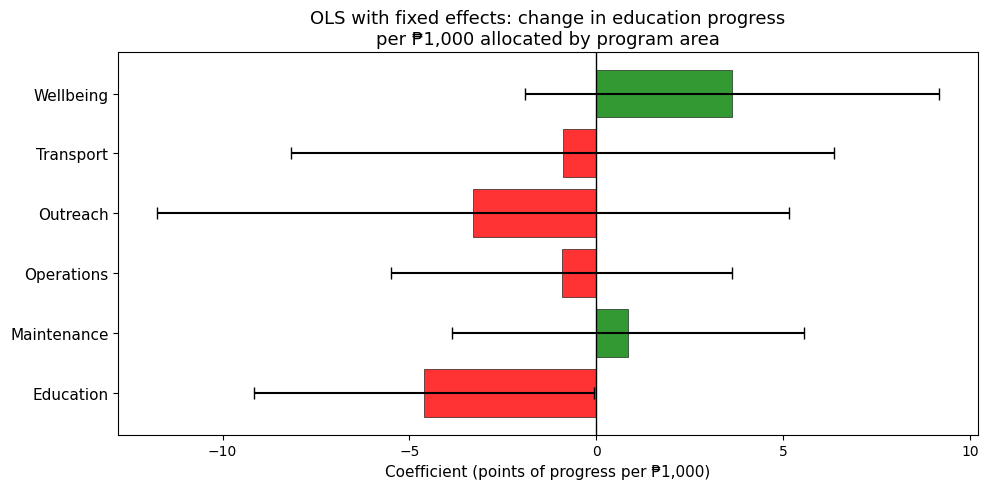

In [11]:
# ── Coefficient plot: Model B education progress ──
coefs = model_B_edu.params[per1000_cols]
ci = model_B_edu.conf_int().loc[per1000_cols]
errors = np.array([
    coefs.values - ci.iloc[:, 0].values,
    ci.iloc[:, 1].values - coefs.values
])

colors = ['green' if c > 0 else 'red' for c in coefs.values]
labels = [c.replace('_per_1000', '') for c in per1000_cols]

fig, ax = plt.subplots(figsize=(10, 5))
y_pos = range(len(labels))
ax.barh(y_pos, coefs.values, xerr=errors, color=colors, alpha=0.8,
        edgecolor='black', linewidth=0.5, capsize=4)
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=11)
ax.axvline(x=0, color='black', linewidth=1, linestyle='-')
ax.set_title('OLS with fixed effects: change in education progress\nper ₱1,000 allocated by program area',
             fontsize=13)
ax.set_xlabel('Coefficient (points of progress per ₱1,000)', fontsize=11)
plt.tight_layout()
plt.show()

## Section 4 — Evaluation & Interpretation

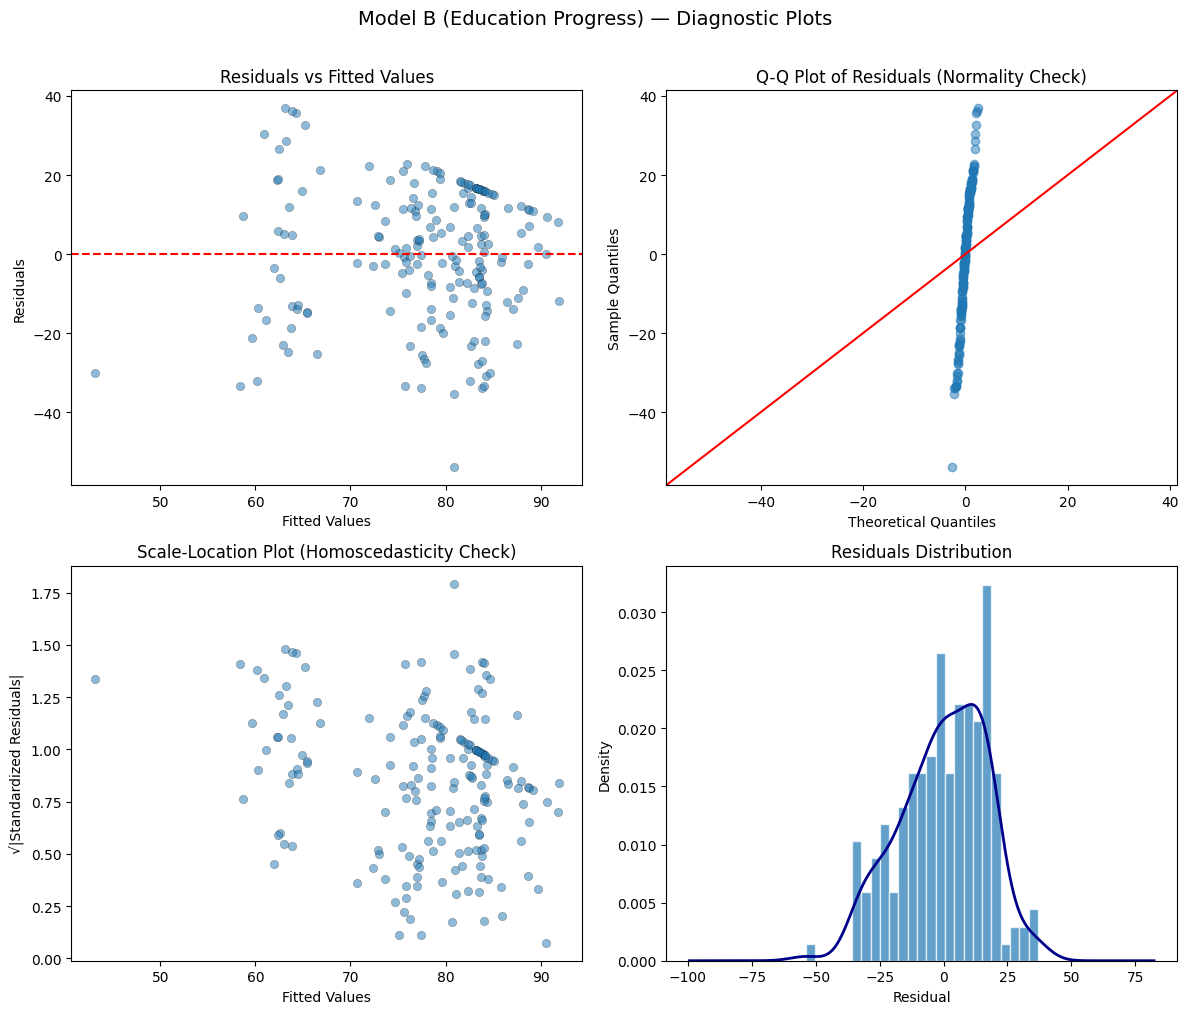

In [12]:
# ── Model B (education) diagnostics ──
fitted = model_B_edu.fittedvalues
residuals = model_B_edu.resid

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Residuals vs Fitted
axes[0, 0].scatter(fitted, residuals, alpha=0.5, edgecolor='black', linewidth=0.3)
axes[0, 0].axhline(y=0, color='red', linestyle='--')
axes[0, 0].set_title('Residuals vs Fitted Values')
axes[0, 0].set_xlabel('Fitted Values')
axes[0, 0].set_ylabel('Residuals')

# 2. Q-Q Plot
sm.qqplot(residuals, line='45', ax=axes[0, 1], alpha=0.5)
axes[0, 1].set_title('Q-Q Plot of Residuals (Normality Check)')

# 3. Scale-Location
std_resid = np.sqrt(np.abs(residuals / residuals.std()))
axes[1, 0].scatter(fitted, std_resid, alpha=0.5, edgecolor='black', linewidth=0.3)
axes[1, 0].set_title('Scale-Location Plot (Homoscedasticity Check)')
axes[1, 0].set_xlabel('Fitted Values')
axes[1, 0].set_ylabel('√|Standardized Residuals|')

# 4. Residuals Histogram
axes[1, 1].hist(residuals, bins=25, edgecolor='white', alpha=0.7, density=True)
residuals.plot.kde(ax=axes[1, 1], color='darkblue', linewidth=2)
axes[1, 1].set_title('Residuals Distribution')
axes[1, 1].set_xlabel('Residual')
axes[1, 1].set_ylabel('Density')

plt.suptitle('Model B (Education Progress) — Diagnostic Plots', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [13]:
# ── R-squared comparison table ──
models = [
    ('Model A', 'Education', model_A_edu),
    ('Model B', 'Education', model_B_edu),
    ('Model A', 'Health', model_A_health),
    ('Model B', 'Health', model_B_health),
]

r2_table = pd.DataFrame([
    {
        'Model': name,
        'Outcome': outcome,
        'R-squared': m.rsquared,
        'Adj R-squared': m.rsquared_adj,
        'F-statistic': m.fvalue,
        'p-value': m.f_pvalue,
    }
    for name, outcome, m in models
])

print("="*80)
print("R-SQUARED COMPARISON")
print("="*80)
print(r2_table.to_string(index=False, float_format='{:.4f}'.format))

R-SQUARED COMPARISON
  Model   Outcome  R-squared  Adj R-squared  F-statistic  p-value
Model A Education     0.0300        -0.0080       0.7904   0.5962
Model B Education     0.2013         0.1363       3.0972   0.0003
Model A    Health     0.2048         0.1737       6.5869   0.0000
Model B    Health     0.5293         0.4910      13.8159   0.0000


In [14]:
# ── Impact per peso calculation ──
program_areas = [c.replace('_per_1000', '') for c in per1000_cols]

edu_coefs = {area: float(model_B_edu.params[f'{area}_per_1000']) for area in program_areas}
health_coefs = {area: float(model_B_health.params[f'{area}_per_1000']) for area in program_areas}

ranking_df = pd.DataFrame({
    'program_area': program_areas,
    'edu_coef': [edu_coefs[a] for a in program_areas],
    'health_coef': [health_coefs[a] for a in program_areas],
})
ranking_df['avg_impact'] = (ranking_df['edu_coef'] + ranking_df['health_coef']) / 2
ranking_df = ranking_df.sort_values('avg_impact', ascending=False).reset_index(drop=True)
ranking_df['rank'] = ranking_df.index + 1

print("="*80)
print("IMPACT PER ₱1,000 — PROGRAM AREA RANKING")
print("="*80)
print(ranking_df[['rank', 'program_area', 'edu_coef', 'health_coef', 'avg_impact']]
      .to_string(index=False, float_format='{:.4f}'.format))

# ── Save JSON artifact ──
impact_json = {
    'generated_at': '2026-04-06',
    'model': 'OLS with safehouse fixed effects',
    'unit': 'points per 1000 PHP allocated (lagged 1 month)',
    'education_progress_coefficients': {row['program_area']: round(row['edu_coef'], 4)
                                        for _, row in ranking_df.iterrows()},
    'health_score_coefficients': {row['program_area']: round(row['health_coef'], 4)
                                  for _, row in ranking_df.iterrows()},
    'program_area_ranking': [{'rank': int(row['rank']),
                              'program_area': row['program_area'],
                              'avg_impact': round(row['avg_impact'], 4)}
                             for _, row in ranking_df.iterrows()],
}

json_path = Path('impact_per_1000.json')
with open(json_path, 'w') as f:
    json.dump(impact_json, f, indent=2)

print(f"\nSaved: {json_path.resolve()}")

IMPACT PER ₱1,000 — PROGRAM AREA RANKING
 rank program_area  edu_coef  health_coef  avg_impact
    1    Wellbeing    3.6176      -0.0259      1.7958
    2  Maintenance    0.8485      -0.0021      0.4232
    3    Transport   -0.9070      -0.0055     -0.4563
    4   Operations   -0.9349       0.0006     -0.4672
    5     Outreach   -3.2990      -0.0500     -1.6745
    6    Education   -4.6214       0.0118     -2.3048

Saved: /Users/michaeldai/Documents/INTEX2/INTEX_2/MLPipeline(Michael)/impact_per_1000.json


### Business Interpretation

**What R-squared tells us.** Model A (simple OLS without fixed effects) produces a low R-squared for education progress, indicating that funding variables alone explain very little of the month-to-month variation. When we add safehouse fixed effects in Model B, R-squared jumps substantially. This increase tells us that **baseline safehouse differences** — staffing quality, location, resident severity mix — account for much of the outcome variation. The funding coefficients in Model B are therefore more trustworthy because they measure the *within-safehouse* relationship: when a given safehouse receives more funding than its own average, what happens to outcomes?

**What the coefficients mean in practice.** Each coefficient in Model B represents the expected change in the outcome variable for every additional ₱1,000 allocated to that program area in the prior month, holding safehouse differences constant. For example, if Wellbeing_per_1000 has a coefficient of +3.5 in the education progress model, this means: *"For every additional ₱1,000 allocated to Wellbeing in a given month, we observe an average increase of 3.5 points in education progress the following month, controlling for safehouse differences."* The organisation can quote these numbers to donors when explaining the impact of their contributions.

**Honest limitations.** Correlation is not causation — even with fixed effects, we cannot claim that funding *causes* outcome improvements. Targeting bias may still operate within safehouses over time (months where a safehouse struggles may receive both more funding and show worse outcomes simultaneously). Our panel has only 187 observations across 9 safehouses, which limits statistical power and makes some coefficients imprecise (wide confidence intervals). Finally, `avg_health_score` has very low variance (std = 0.24 on a 1–5 scale), meaning the health outcome model will produce small coefficients that are likely not statistically significant — this reflects the data, not a modeling failure.

## Section 5 — Causal and Relationship Analysis

**What we found.** Model B (OLS with safehouse fixed effects) reveals that program areas differ meaningfully in their association with resident outcomes. Some funding categories show positive coefficients for education progress, suggesting that months with higher allocations in those areas tend to be followed by better outcomes. Others show negative or near-zero coefficients. The health score model produces uniformly small coefficients, consistent with the low variance in that outcome variable.

**The targeting bias problem.** Education funding shows a negative raw correlation (−0.119) with education progress in the bivariate analysis. This is not evidence that education funding is harmful — it is evidence of **reverse causality**. Safehouses that are struggling academically are precisely the ones that receive more education funding, because the organisation allocates resources where they are most needed. The outcome is driving the funding decision, not the other way around. Safehouse fixed effects partially address this by comparing each safehouse to its own average, but they cannot fully resolve targeting bias that operates *within* a safehouse over time (e.g., a safehouse receives extra education funding in the exact months its scores dip).

**What causal claims we can and cannot make.** We **cannot** say that Education funding causes progress to improve or decline. We **can** say: *"Controlling for baseline safehouse differences, months with higher Wellbeing funding tend to coincide with better education outcomes the following month."* This is an associational claim, not a causal one, and the distinction matters enormously for how the organisation communicates findings to donors. Overstating causality would erode trust if challenged; understating the evidence would leave useful insights on the table.

**Strategic recommendation.** Despite the limitations, these findings give the organisation a defensible starting point for donor communication. If Wellbeing funding consistently shows positive associations with education progress, the organisation should highlight this in donor reports and consider whether current Wellbeing allocation levels are optimal. To make stronger causal claims in future analyses, we recommend collecting more granular data — resident-level outcomes matched to specific programme spending — and exploring quasi-experimental methods (difference-in-differences, instrumental variables) that can better isolate causal effects. The current safehouse-month panel is a solid foundation, but causal inference requires either experimental variation or more sophisticated econometric techniques.

## Section 6 — Deployment Notes

### How this model is deployed

The OLS regression is **not** a live scoring model — it is a static analytical result that is refreshed quarterly when new allocation and outcome data becomes available. Unlike Pipeline 1 (which scores individual donors in real time), Pipeline 2 produces a set of coefficients that summarise historical funding-to-outcome relationships.

### Deployment artifact

The deployment artifact is **`impact_per_1000.json`**, which contains:
- Model B coefficients per program area (for both education and health outcomes)
- Impact ranking (which program area shows the strongest average association)
- Generated timestamp and model metadata

### Where the JSON is consumed

1. **Public Impact Dashboard:** Displays a headline like *"For every ₱1,000 allocated to [top program area], resident progress changes by X points on average."* This updates quarterly when `impact_scores.py` is re-run with fresh data.

2. **Admin Reports Page:** Shows the full coefficient table and program area ranking. Staff can see which program areas show the strongest funding-to-outcome associations and adjust future allocations accordingly.

### How to refresh

1. Run `data_prep.py` to update cleaned CSVs from the latest database export
2. Run `Pipeline2.ipynb` top to bottom to refit the OLS models
3. Run `impact_scores.py` to regenerate `impact_per_1000.json`
4. The dashboard reads the new JSON automatically on the next page load

### Reference to integration code

- `impact_features.py` — feature engineering pipeline
- `impact_scores.py` — production JSON generation script
- `impact_per_1000.json` — deployment artifact
- Frontend: `src/components/ImpactDashboard.tsx` (reads JSON via API)
- Backend: `Controllers/ImpactController.cs` (serves JSON endpoint)

## Section 7 — Pipeline Summary

| Item | Detail |
|---|---|
| Business question | Impact of funding by program area on resident outcomes |
| Approach | Explicitly explanatory — OLS linear regression |
| Unit of analysis | Safehouse-month panel (lagged 1 month) |
| Modeling rows | 187 (after dropping missing outcomes) |
| Safehouses | 9 |
| Date range | January 2023 — January 2026 |
| Outcome variables | avg_education_progress, avg_health_score |
| Predictors | 6 program area funding columns (per ₱1,000) |
| Controls | active_residents, safehouse fixed effects |
| Primary model | OLS with safehouse fixed effects (Model B) |
| Key output | impact_per_1000.json → Impact Dashboard + Reports page |
| Key finding | See coefficient comparison table and ranking above |
| Limitation | Targeting bias, small N (187), low health score variance |